<a href="https://colab.research.google.com/github/babistranger/Data-Analytics-with-AI---Studies/blob/main/Forecasting_Barbara_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

In [ ]:
import statsmodels.api as sm

In [ ]:
import statsmodels.tsa.api as tsa

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.9 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

In [ ]:
#Carregando os Dados
dados = pd.read_csv('dengue_pernambuco.csv', delimiter=',')

In [ ]:
#Visualizando os dados
dados.head()


,semana,valor
0,2000-01-08,686
1,2000-01-15,611
2,2000-01-22,614
3,2000-01-29,598
4,2000-02-05,785


In [ ]:
#Calculando a série
serie = dados['valor']

In [ ]:
dados = dados.set_index('semana')

<Axes: xlabel='semana'>

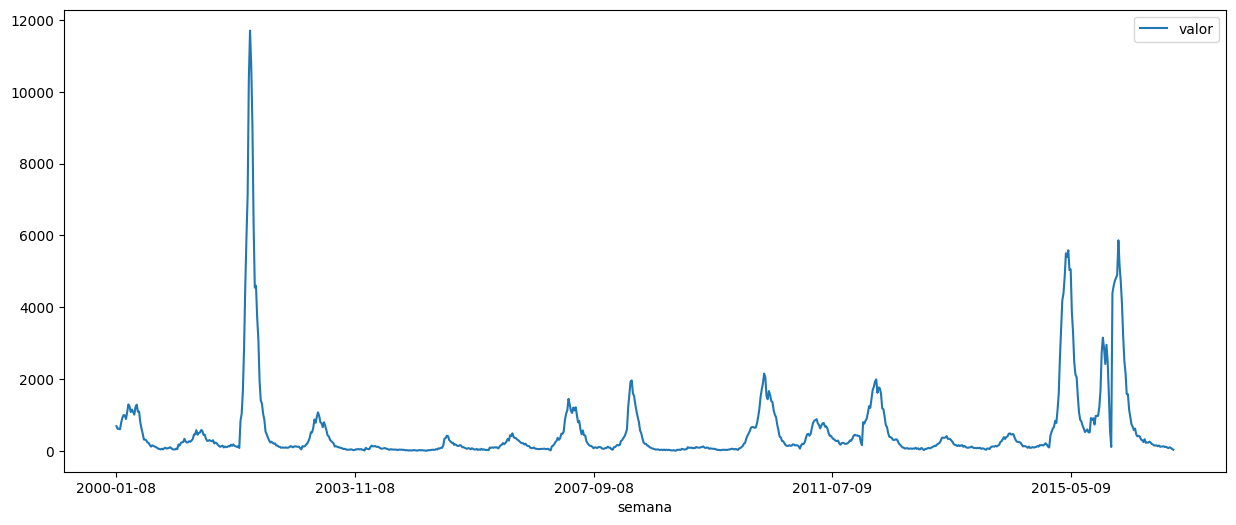

In [ ]:
#plotando os dados
dados.plot()

In [ ]:
#Identificando valores nulos
#df.isnull().values.any() - identifica algum valor nulo
dados.isnull().values.sum()

0

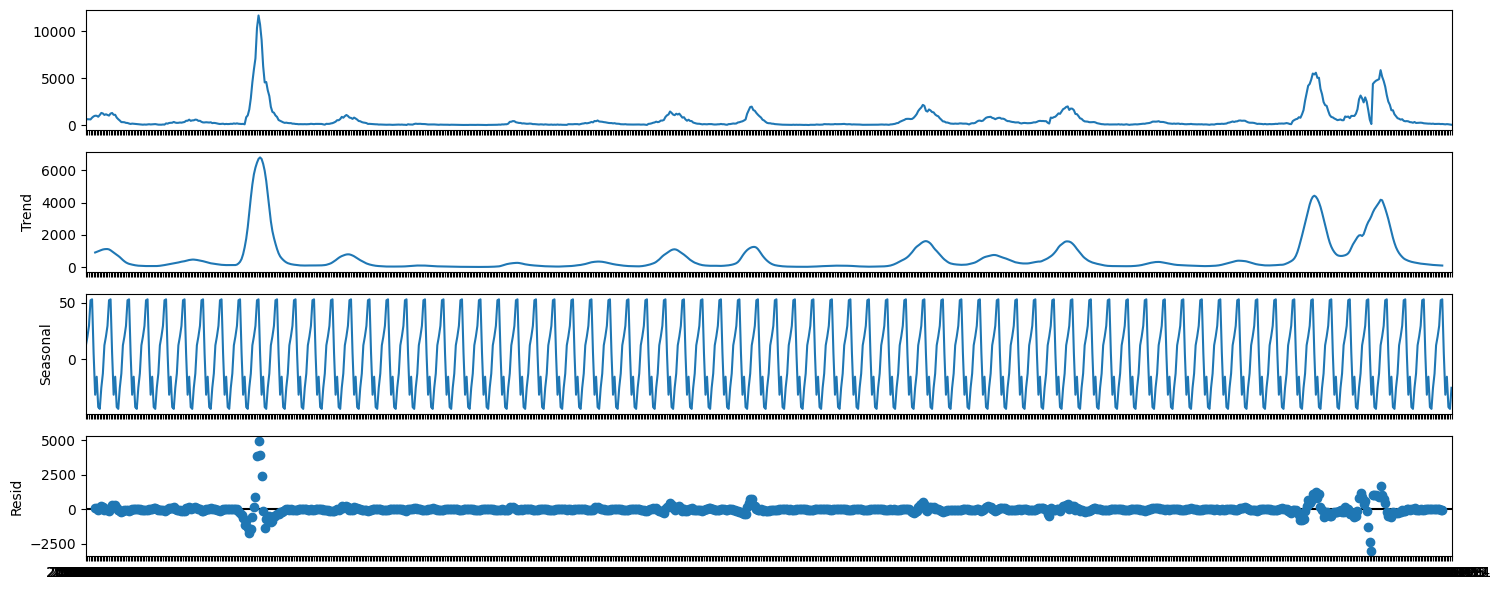

In [ ]:
dados_decomp = tsa.seasonal_decompose(dados, period  = 12) #decomposição da função
dados_decomp.plot();

A série não tem tendência, apenas sazonalidade. Logo, a componente tendência da função que define a série é nula.
Já se observa como será difícil prever algo a partir desse conjunto de dados.

In [ ]:
#Cálculo da média móvel
rolmean12 = dados.rolling(window=12).mean()
rolmean12.head(15)

,valor
semana,
2000-01-08,NaN
2000-01-15,NaN
2000-01-22,NaN
2000-01-29,NaN
2000-02-05,NaN
2000-02-12,NaN
2000-02-19,NaN
2000-02-26,NaN
2000-03-04,NaN


In [ ]:
#Cálculo do desvio padrão
rolstd12 = dados.rolling(window=12).std()
rolstd12

,valor
semana,
2000-01-08,NaN
2000-01-15,NaN
2000-01-22,NaN
2000-01-29,NaN
2000-02-05,NaN
...,...
2016-12-03,23.128102
2016-12-10,22.034924
2016-12-17,21.027399


In [ ]:
rolmean6 = dados.rolling(window=6).mean()

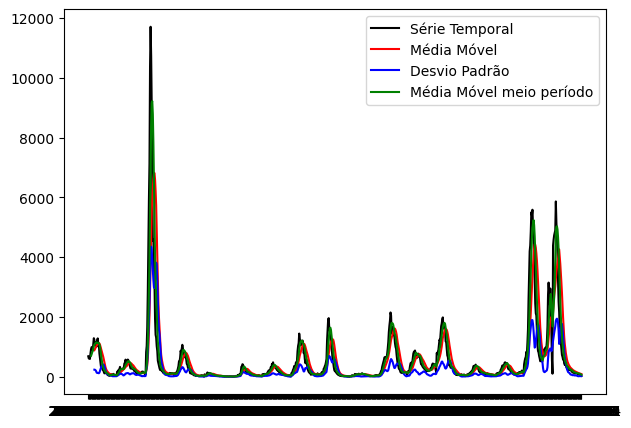

In [ ]:
plt.figure(figsize=(7, 5))

actual = plt.plot(dados['valor'], color = 'black', label = 'Série Temporal')
plt.plot(rolmean12, color = 'red', label = 'Média Móvel')
plt.plot(rolstd12, color = 'blue', label = 'Desvio Padrão')
plt.plot(rolmean6, color = 'green', label = 'Média Móvel meio período')
plt.legend(loc='best')




plt.show()

In [ ]:
adfuller(dados['valor'])

(-5.663070483050525,
 9.283989595165777e-07,
 14,
 872,
 {'1%': -3.4378713927343156,
  '5%': -2.8648601928465505,
  '10%': -2.568537914369582},
 12016.493679786781)

Rejeitada a hipótese de série não estacionária. A série é estacionária. p valor menor que 0,95.
Observo que não preciso aplicar diferenciação porque a série já é estacionária.

In [ ]:
# Plotar o ACF e PACF - autocorrelação e autocorrelação parcial
def acf_pacf(x, qtd_lag):
    fig = plt.figure(figsize=(16,10))
    ax1 = fig.add_subplot(221)
    fig = sm.graphics.tsa.plot_acf(x, lags=qtd_lag, ax=ax1)
    ax2 = fig.add_subplot(222)
    fig = sm.graphics.tsa.plot_pacf(x, lags=qtd_lag, ax=ax2)
    plt.show()

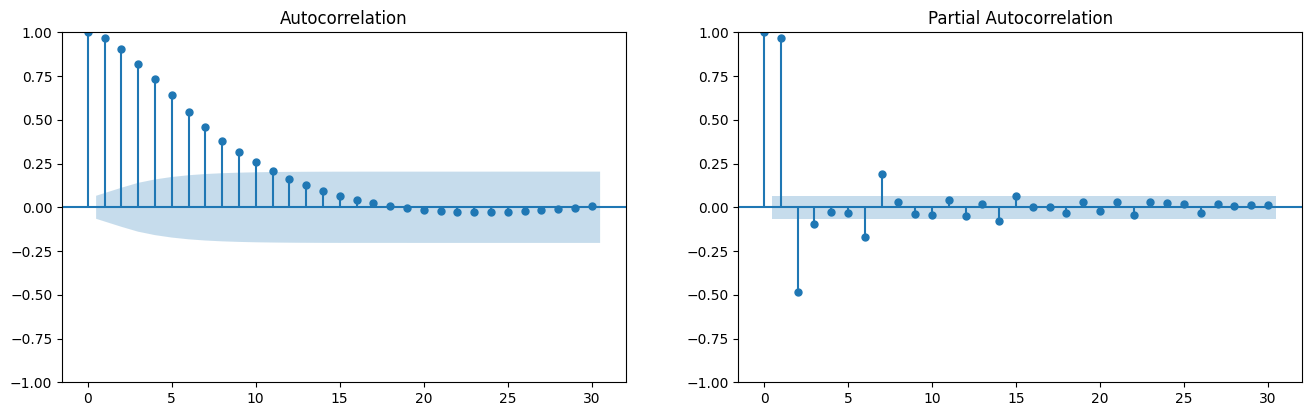

In [ ]:
acf_pacf(dados['valor'],30)

A autocorrelação nos mostra que é a curto prazo

# Modelo ARIMA
(Poderia ser ARMA, porque a série é estacionária ?)

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir 75% para treino e 25% para teste, não precisa definir percentual de validação no modelo Arima
train, test = train_test_split(dados, test_size=0.25, shuffle=False)

In [ ]:
modelo_autoarima = pm.auto_arima (train, max_p=5, max_q=5,max_d=2,
                                  max_P=2, max_Q=2, max_D=2, m=12,
                                  seasonal = False, trace = True,
                                  information_criterion = 'bic',
                                  stewise = True)

Performing stepwise search to minimize bic
 ARIMA(2,0,2)(0,0,0)[0]             : BIC=8878.776, Time=2.33 sec
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=11244.326, Time=0.21 sec
 ARIMA(1,0,0)(0,0,0)[0]             : BIC=9270.426, Time=0.14 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=inf, Time=0.98 sec
 ARIMA(1,0,2)(0,0,0)[0]             : BIC=8929.880, Time=0.88 sec
 ARIMA(2,0,1)(0,0,0)[0]             : BIC=8874.694, Time=0.48 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=8956.767, Time=2.00 sec
 ARIMA(2,0,0)(0,0,0)[0]             : BIC=8870.240, Time=0.49 sec
 ARIMA(3,0,0)(0,0,0)[0]             : BIC=8874.958, Time=1.30 sec
 ARIMA(3,0,1)(0,0,0)[0]             : BIC=8865.112, Time=1.97 sec
 ARIMA(4,0,1)(0,0,0)[0]             : BIC=8871.488, Time=6.80 sec
 ARIMA(3,0,2)(0,0,0)[0]             : BIC=8871.503, Time=3.07 sec
 ARIMA(4,0,0)(0,0,0)[0]             : BIC=8880.548, Time=1.27 sec
 ARIMA(4,0,2)(0,0,0)[0]             : BIC=8864.852, Time=4.17 sec
 ARIMA(5,0,2)(0,0,0)[0]             :

Como verificado, os melhores ajustes para p, d e q são p=4, d=0 (não precisa diferenciar), q = 2.

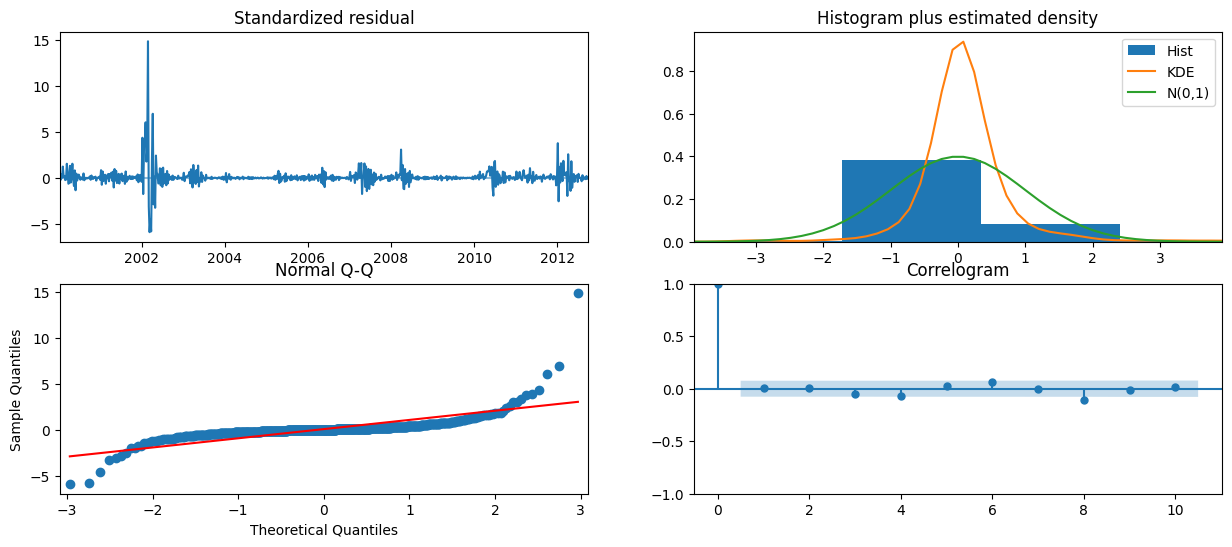

In [ ]:
modelo_autoarima.plot_diagnostics();

In [ ]:
print(modelo_autoarima.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  665
Model:               SARIMAX(4, 0, 2)   Log Likelihood               -4409.677
Date:                Sat, 05 Oct 2024   AIC                           8833.353
Time:                        16:48:38   BIC                           8864.852
Sample:                    01-08-2000   HQIC                          8845.558
                         - 09-29-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1206      0.054      2.223      0.026       0.014       0.227
ar.L2          0.9659      0.053     18.248      0.000       0.862       1.070
ar.L3          0.3383      0.045      7.595      0.0

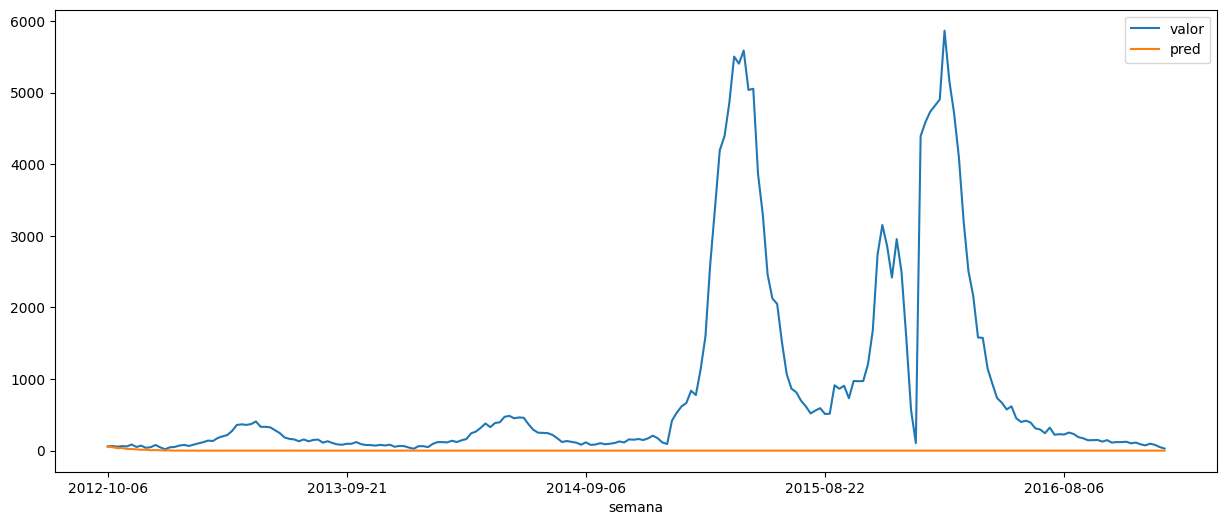

In [ ]:
#Previsão geral (reta é porque é calculada em cima dos valores futuros)
pred = modelo_autoarima.predict(n_periods = len(dados))
pred_df = pd.DataFrame(pred, index = test.index, columns = ['pred'])
pred_df = pd.concat([test,pred_df], axis=1)
pred_df.plot();

<Axes: xlabel='semana'>

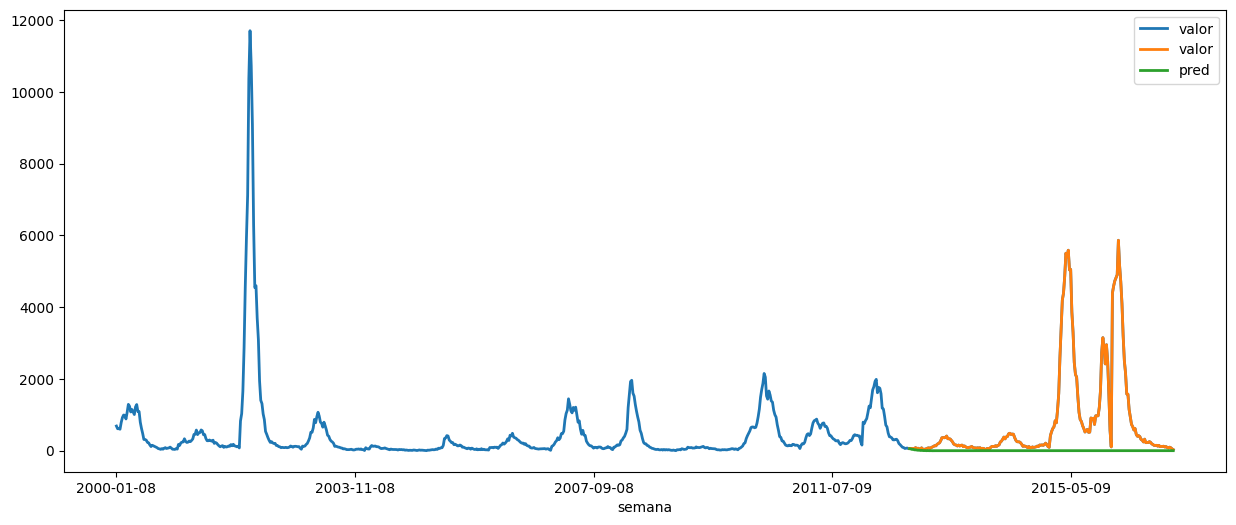

In [ ]:
pd.concat([dados,pred_df], axis=1).plot(linewidth=2)

In [ ]:
#Cálculo estatístico MAE e MSE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

print('Modelo Autoarima')
mse_autoarima = round(mean_squared_error(pred_df.valor, pred_df.pred),2)
mae_autoarima = round(mean_absolute_error(pred_df.valor, pred_df.pred),2)
print(mse_autoarima)
print(mae_autoarima)

Modelo Autoarima
2612057.6
841.32


In [ ]:
# Cáluco do MAPE arima
mape_autoarima = mean_absolute_percentage_error(pred_df.valor, pred_df.pred)

print(mape_autoarima)

0.9783321882422322


# Previsão um passo à frente

In [ ]:
model = ARIMA(serie, order=(4, 0, 2))
model_fit = model.fit()

In [ ]:
#Fazendo a previsão de um passo à frente
forecast = model_fit.forecast(steps=1)
print("Previsão um passo à frente:", forecast)

Previsão um passo à frente: 887    45.831085
dtype: float64


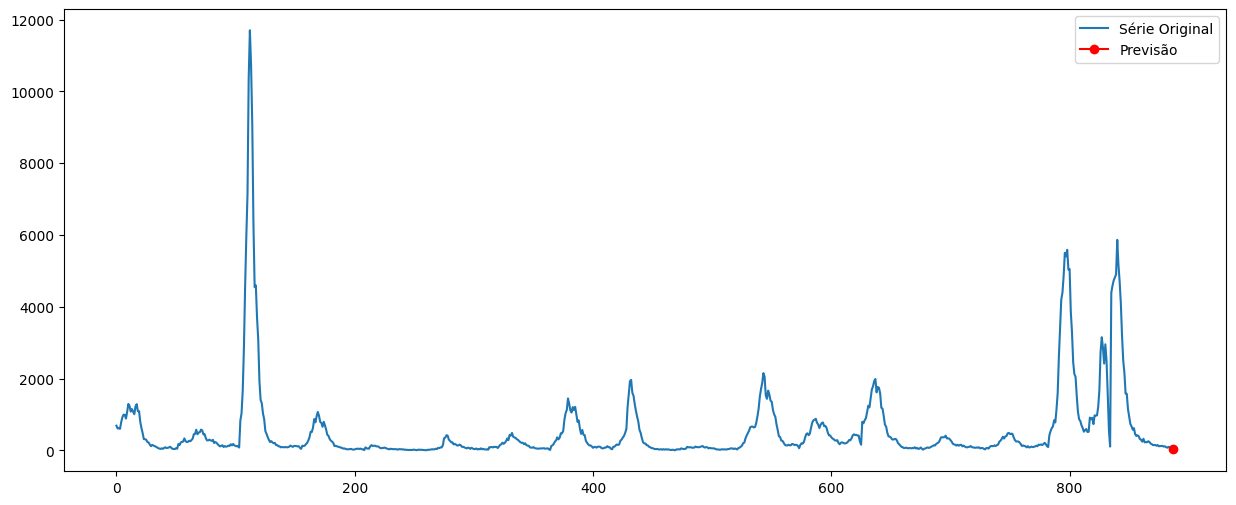

In [ ]:
#Previsão Geral
plt.plot(serie, label='Série Original')
plt.plot(len(serie), forecast, marker='o', color='red', label='Previsão')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT 

                               SARIMAX Results                                
Dep. Variable:                  valor   No. Observations:                  222
Model:                 ARIMA(4, 0, 2)   Log Likelihood               -2026.277
Date:                Sat, 05 Oct 2024   AIC                           4068.554
Time:                        16:48:44   BIC                           4095.775
Sample:                    10-06-2012   HQIC                          4079.544
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.0099    245.301      1.851      0.064     -26.772     934.791
ar.L1          0.1190      0.054      2.200      0.028       0.013       0.225
ar.L2          0.9507      0.053     17.894      0.0

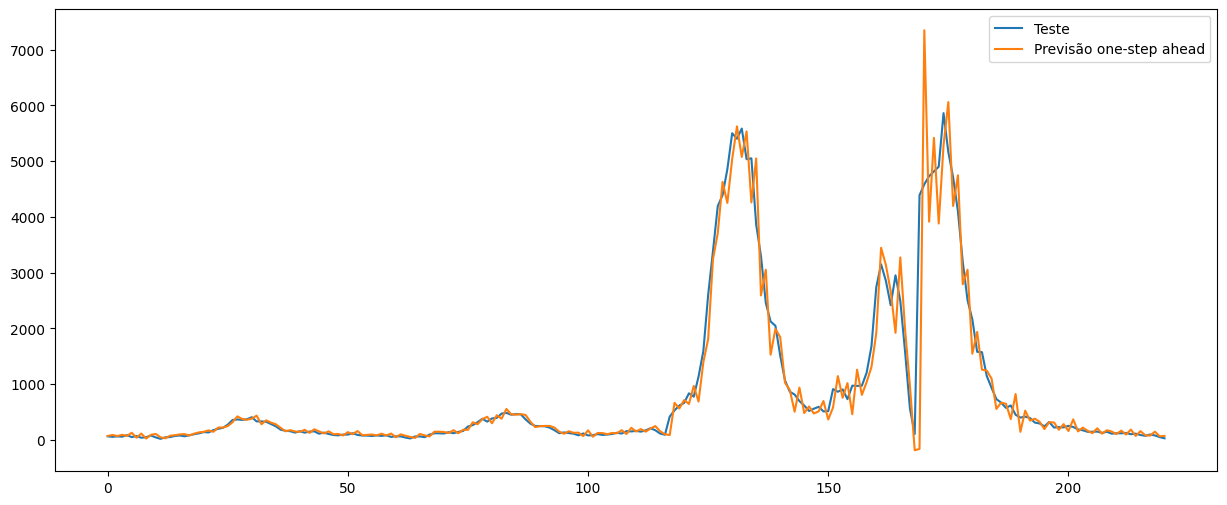

In [ ]:
#Previsão one-step ahead
arima = ARIMA(train, order=(4,0,2)).fit()
arima_teste2 = arima.apply(test)
print(arima_teste2.summary())

pred2 = arima_teste2.predict().iloc[1:].values
test_2 = test.iloc[1:].values

fig, ax = plt.subplots()
ax.plot(test_2, label='Teste')
ax.plot(pred2, label='Previsão one-step ahead')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

results = {}

print('ARIMA model Results com One-Step')
results['ARIMA'] = {'MAE': round(mean_absolute_error(test_2, pred2), 4),
                  'MSE': round(mean_squared_error(test_2, pred2), 4),
                  'MAPE': round(mean_absolute_percentage_error(test_2, pred2),4),
                  'R^2': round(r2_score(test_2, pred2), 4)
                  }
results

ARIMA model Results com One-Step


{'ARIMA': {'MAE': 178.5062, 'MSE': 198594.4885, 'MAPE': 0.2988, 'R^2': 0.8959}}

## Definições antes da modelagem





In [ ]:
# Usando Janelas Deslizantes (Sliding Windows) para definição dos dados a serem usados nos conjuntos
def get_lags(serie, lags):
  result = []

  if lags > 0:
    for lag in range(1, lags+1):
      result.append(serie.shift(lag).rename({serie.columns[0]: serie.columns[0]+'-'+str(lag)}, axis=1))
    return pd.concat(result, axis=1, names=list(range(-1,-lags))).dropna()

  else:
    for lag in range(-1, lags-1,-1):
      result.append(serie.shift(lag).rename({serie.columns[0]: serie.columns[0]+'+'+str(abs[0]+'+'+str(abs(lag)))}, axis=1))
    return pd.concat(result, axis=1, names=list(range(+1,-lags))).dropna()

In [ ]:
df_janelas = get_lags(dados, 12)
df_janelas.head()

,valor-1,valor-2,valor-3,valor-4,valor-5,valor-6,valor-7,valor-8,valor-9,valor-10,valor-11,valor-12
semana,,,,,,,,,,,,
2000-04-01,1236.0,1291.0,1073.0,884.0,986.0,993.0,923.0,785.0,598.0,614.0,611.0,686.0
2000-04-08,1079.0,1236.0,1291.0,1073.0,884.0,986.0,993.0,923.0,785.0,598.0,614.0,611.0
2000-04-15,1148.0,1079.0,1236.0,1291.0,1073.0,884.0,986.0,993.0,923.0,785.0,598.0,614.0
2000-04-22,1077.0,1148.0,1079.0,1236.0,1291.0,1073.0,884.0,986.0,993.0,923.0,785.0,598.0
2000-04-29,1007.0,1077.0,1148.0,1079.0,1236.0,1291.0,1073.0,884.0,986.0,993.0,923.0,785.0


In [ ]:
# Definindo x e y (o target)
X = df_janelas
y = dados.reindex(X.index)
X
y

,valor
semana,
2000-04-01,1079
2000-04-08,1148
2000-04-15,1077
2000-04-22,1007
2000-04-29,1221
...,...
2016-12-03,73
2016-12-10,97
2016-12-17,80


# Modelo da Regressão Linear


In [ ]:
n = len(df_janelas)
n_trainreg = int(0.75 * n)
n_testreg = n - n_trainreg

In [ ]:
# Separar features (X) e target (y)
X_trainreg, y_trainreg = X[:n_trainreg], y[:n_trainreg]
X_testreg, y_testreg = X[n_trainreg:],y[n_trainreg:]

In [ ]:
# Criando o modelo de Regressão Linear
linear_model = LinearRegression()
linear_model.fit(X_trainreg, y_trainreg)

# Avaliação e previsão no conjunto de treinamento
y_predreg = linear_model.predict(X_testreg)

In [ ]:
#Avaliando o modelo de Regressão Linear
mse = mean_squared_error(y_testreg, y_predreg)
rmse= np.sqrt(mse)
r2 = r2_score(y_testreg, y_predreg)
mae = mean_absolute_error(y_testreg, y_predreg)

print(f"Coeficientes: {linear_model.coef_}")
print(f"Intercepto: {linear_model.intercept_}")
print(f"R²: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")


Coeficientes: [[ 1.68849916 -0.8319949   0.21980142 -0.34924931  0.42603662 -0.20262696
  -0.0520389   0.00642896  0.02708177  0.14882319 -0.21003985  0.08020279]]
Intercepto: [21.37745124]
R²: 0.8959320390470196
RMSE: 446.97486556061824
MAE: 172.88121342522865
MSE: 199786.53044293277


In [ ]:
# Avaliação o Modelo de Regressão e armazenamento num vetor
results['REGRESSÃO_LINEAR'] = {'MAE': round(mean_absolute_error(y_testreg, y_predreg), 4),
                  'MSE': round(mean_squared_error(y_testreg, y_predreg), 4),
                  'MAPE': round(mean_absolute_percentage_error(y_testreg, y_predreg),4),
                  'R^2': round(r2_score(y_testreg, y_predreg), 4)}
results

{'MAE': 143.4733,
 'MSE': 65074.639,
 'MAPE': 0.4146,
 'R^2': 0.7416,
 'KNN': {'MAE': 143.4733, 'MSE': 65074.639, 'MAPE': 0.4146, 'R^2': 0.7416},
 'MLP': {'MAE': 96.1921, 'MSE': 26972.1305, 'MAPE': 0.3161, 'R^2': 0.8929},
 'REGRESSÃO_LINEAR': {'MAE': 172.8812,
  'MSE': 199786.5304,
  'MAPE': 0.2923,
  'R^2': 0.8959}}

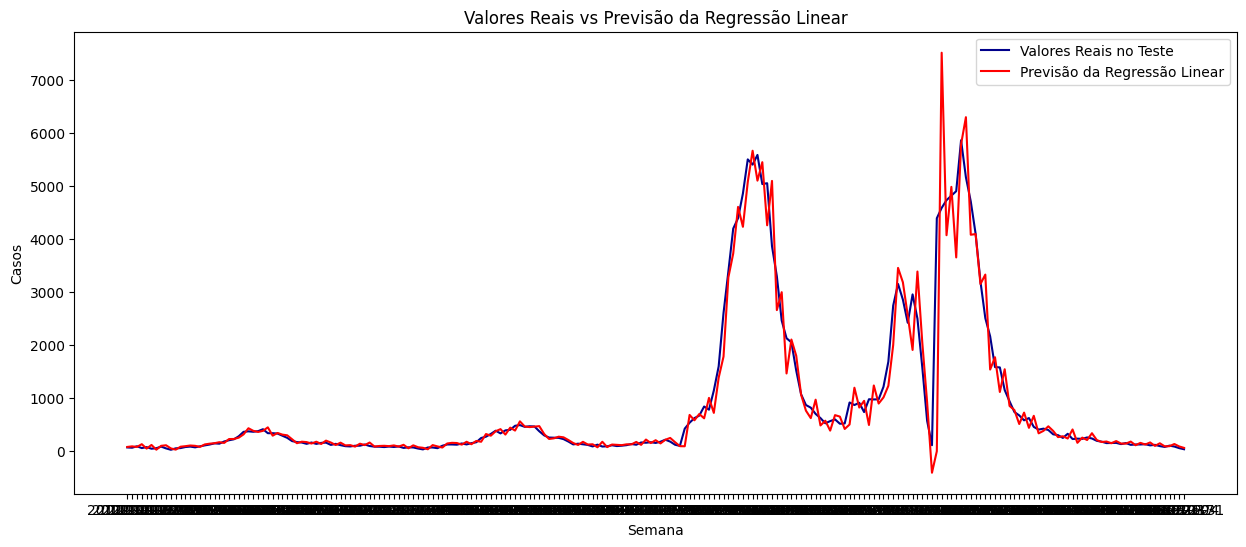

In [ ]:
# Plotando os resultados
plt.plot(y_testreg.index, y_testreg, label='Valores Reais no Teste', color='darkblue')
plt.plot(y_testreg.index, y_predreg, label='Previsão da Regressão Linear', color='red')

plt.title('Valores Reais vs Previsão da Regressão Linear')
plt.xlabel('Semana')
plt.ylabel('Casos')
plt.legend()
plt.show()


## Modelo MLP


In [ ]:
# Dividindo os dados em treino, validação e teste (50%, 25% e 25%)
n = len(df_janelas)
n_train= int(0.5 * n)
n_val = int(0.25 * n)
n_test = n - n_train - n_val

In [ ]:
#Definindo Porcentagem de Treino e Teste (50% treino, 25% teste e 25% validação)
train_size = 0.5
train_len = int(len(serie) * train_size)
train, test = serie[:train_len], serie[train_len:]

In [ ]:
# Separando os conjuntos de treino e validação a partir de vetores
X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train: n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:],y[n_train+n_val:]

In [ ]:
# Encontrando os melhores parâmetros do MLP e com o TimeSeriesSplit no cross validation
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

param_MLP = {
    'hidden_layer_sizes': [(30), (100), (10), (20), (10,30), (100,100)],
    'activation': ['relu', 'tanh', 'logistic','identity'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1]}

In [ ]:
# Melhores parâmetros
grid_search_mlp = GridSearchCV(
    MLPRegressor(random_state=1, max_iter=500),
    param_MLP,
    cv = TimeSeriesSplit(5),
    n_jobs=-1
    )

grid_search_mlp.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=MLPRegressor(max_iter=500, random_state=1), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh', 'logistic', 'identity'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [30, 100, 10, 20, (10, 30),
                                                (100, 100)],
                         'learning_rate_init': [0.001, 0.01, 0.1],
                         'solver': ['adam', 'sgd']})

In [ ]:
print(f"Melhores parâmetros: {grid_search_mlp.best_params_}")

Melhores parâmetros: {'activation': 'identity', 'alpha': 0.0001, 'hidden_layer_sizes': 10, 'learning_rate_init': 0.1, 'solver': 'adam'}


In [ ]:
# Aplicando os melhores parâmetros do MPL
mlp = MLPRegressor(
    activation='relu',
    alpha=0.0001,
    hidden_layer_sizes=30,
    learning_rate_init=0.01,
    solver='adam',
    max_iter=1000,  # Número máximo de iterações
    random_state=42)

mlp.fit(X_train,y_train)

MLPRegressor(hidden_layer_sizes=30, learning_rate_init=0.01, max_iter=1000,
             random_state=42)

In [ ]:
# Fazendo a previsão e verificando os erros associados
y_mlp = mlp.predict(X_val)

results['MLP'] = {'MAE': round(mean_absolute_error(y_val, y_mlp), 4),
                  'MSE': round(mean_squared_error(y_val, y_mlp), 4),
                  'MAPE': round(mean_absolute_percentage_error(y_val, y_mlp),4),
                  'R^2': round(r2_score(y_val, y_mlp), 4)
                  }
results

{'MAE': 143.4733,
 'MSE': 65074.639,
 'MAPE': 0.4146,
 'R^2': 0.7416,
 'KNN': {'MAE': 143.4733, 'MSE': 65074.639, 'MAPE': 0.4146, 'R^2': 0.7416},
 'MLP': {'MAE': 96.1921, 'MSE': 26972.1305, 'MAPE': 0.3161, 'R^2': 0.8929},
 'REGRESSÃO_LINEAR': {'MAE': 172.8812,
  'MSE': 199786.5304,
  'MAPE': 0.2923,
  'R^2': 0.8959}}

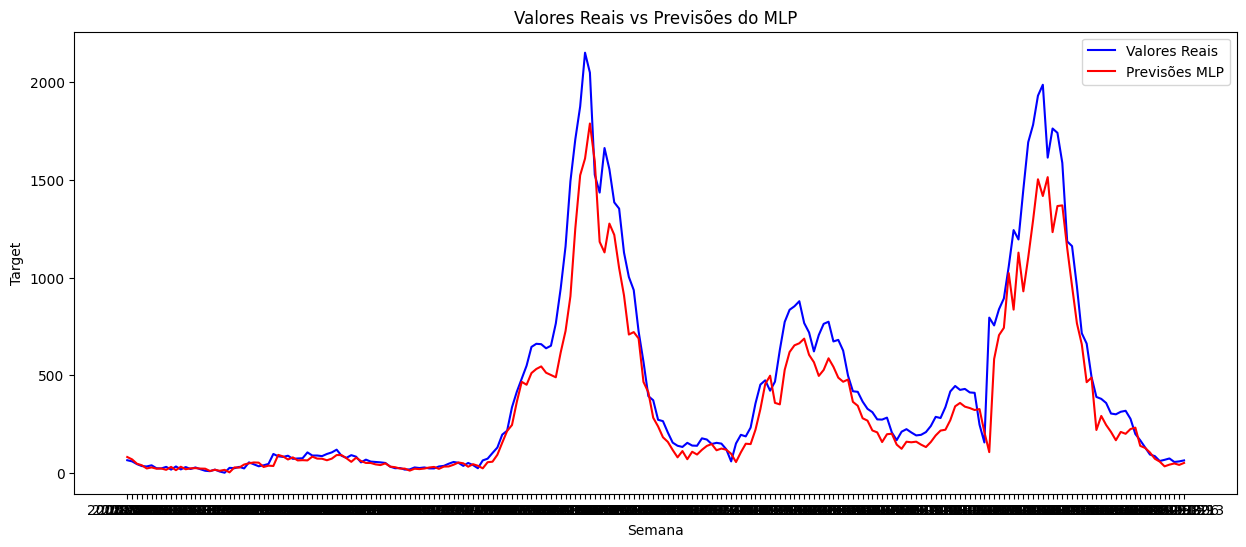

In [ ]:
# Plotando o gráfico do MLP
plt.plot(y_val.index, y_val, label='Valores Reais', color='blue')
plt.plot(y_val.index, y_mlp, label='Previsões MLP', color='red')

plt.title('Valores Reais vs Previsões do MLP')
plt.xlabel('Semana')
plt.ylabel('Target')
plt.legend()
plt.show()

## Modelo KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

param_KNN = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan','cosine','minkowski']
}

In [ ]:
#Melhores parâmetros do KNN
grid_search_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_KNN,
    cv = TimeSeriesSplit(5),
    n_jobs=-1,
    verbose=1
    )

grid_search_knn.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'cosine',
                                    'minkowski'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             verbose=1)

In [ ]:
print(f"Melhores parâmetros KNN: {grid_search_knn.best_params_}")

Melhores parâmetros KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}


In [ ]:
#KNN com os melhores parâmetros
model_knn = KNeighborsRegressor(metric = 'manhattan',n_neighbors=3, weights='distance')
model_knn.fit(X_train, y_train)
y_knn = model_knn.predict(X_val)

In [ ]:
# Avaliando o modelo
results['KNN'] = {'MAE': round(mean_absolute_error(y_val, y_knn), 4),
                  'MSE': round(mean_squared_error(y_val, y_knn), 4),
                  'MAPE': round(mean_absolute_percentage_error(y_val, y_knn),4),
                  'R^2': round(r2_score(y_val, y_knn), 4)
                  }
results

{'MAE': 143.4733,
 'MSE': 65074.639,
 'MAPE': 0.4146,
 'R^2': 0.7416,
 'KNN': {'MAE': 143.4733, 'MSE': 65074.639, 'MAPE': 0.4146, 'R^2': 0.7416},
 'MLP': {'MAE': 96.1921, 'MSE': 26972.1305, 'MAPE': 0.3161, 'R^2': 0.8929},
 'REGRESSÃO_LINEAR': {'MAE': 172.8812,
  'MSE': 199786.5304,
  'MAPE': 0.2923,
  'R^2': 0.8959}}

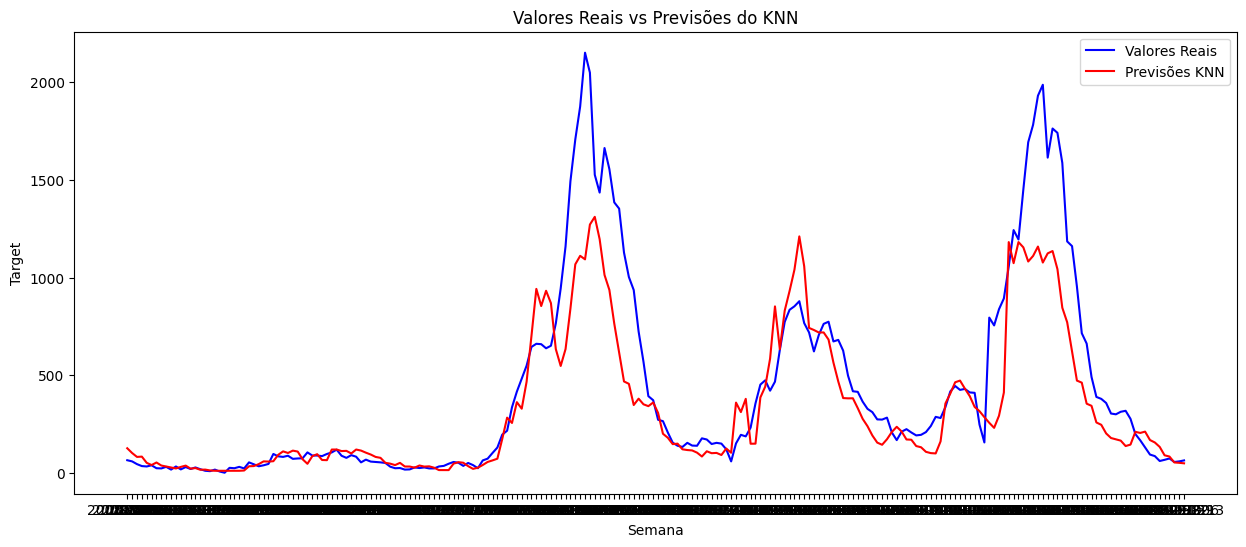

In [ ]:
# Plotando o gráfico do KNN
plt.plot(y_val.index, y_val, label='Valores Reais', color='blue')
plt.plot(y_val.index, y_knn, label='Previsões KNN', color='red')

plt.title('Valores Reais vs Previsões do KNN')
plt.xlabel('Semana')
plt.ylabel('Target')
plt.legend()
plt.show()

#Comparações dos Modelos



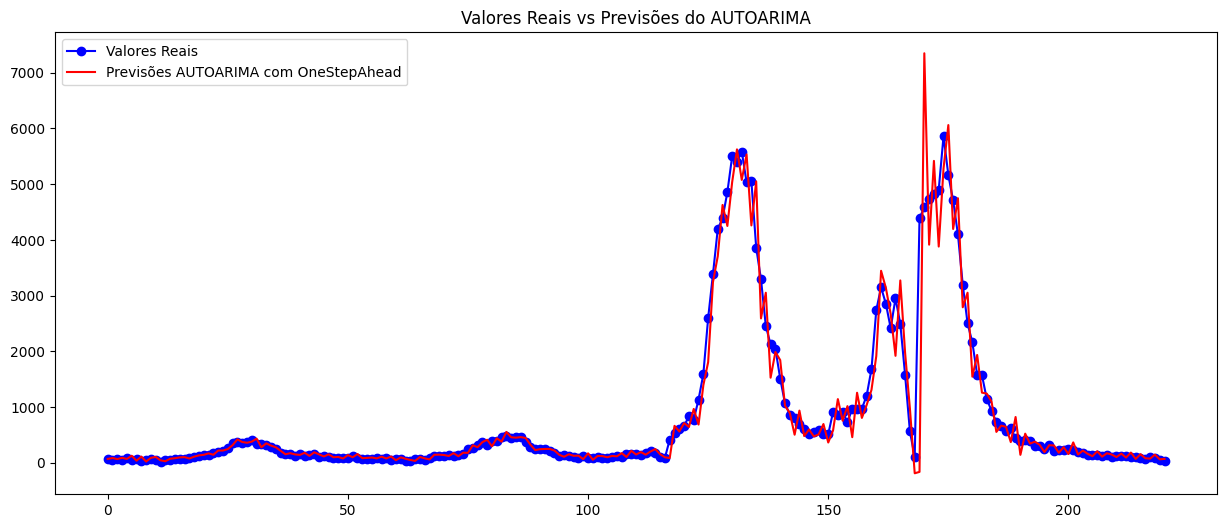

In [ ]:
#Autoarima e série com valores reais
fig, ax = plt.subplots()
ax.plot(test_2, label='Valores Reais', color='blue', marker = 'o')
ax.plot(pred2, label='Previsões AUTOARIMA com OneStepAhead', color='red')
plt.title('Valores Reais vs Previsões do AUTOARIMA')
plt.legend()
plt.show()

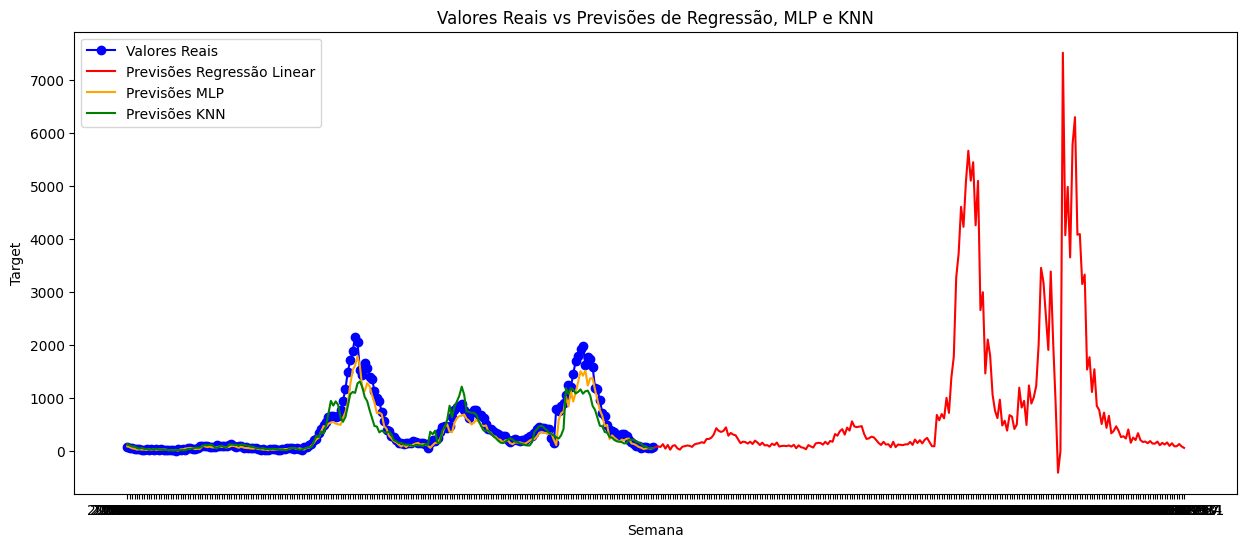

In [ ]:
# MACHINE LEARNING
plt.plot(y_val.index, y_val, label='Valores Reais', color='blue', marker = 'o')
plt.plot(y_testreg.index, y_predreg, label='Previsões Regressão Linear', color='red')
plt.plot(y_val.index[:len(y_mlp)], y_mlp, label='Previsões MLP', color='orange')
plt.plot(y_val.index, y_knn, label='Previsões KNN', color='green')

plt.title('Valores Reais vs Previsões de Regressão, MLP e KNN')
plt.xlabel('Semana')
plt.ylabel('Target')
plt.legend()
plt.show()

In [ ]:
# Criando tabela comparativa com os resultados e diagnósticos dos erros de previsão
round(pd.DataFrame(results),3)

,ARIMA
MAE,178.506
MSE,198594.488
MAPE,0.299
R^2,0.896
